# GNN - 1
## ESOL Dataset
### Abir Hossain

In [1]:
import torch

# Get the pre-installed PyTorch version
TORCH = torch.__version__.split('+')[0]  ## 2.4.0+cu121 or 2.3.1+cpu to the nice 2.10.0 version output.
CUDA = 'cpu' if not torch.cuda.is_available() else f"cu{torch.version.cuda.replace('.', '')}"

print(f"PyTorch Version: {TORCH}")
print(f"CUDA Extension Version: {CUDA}")

# Install PyG dependencies cleanly
!pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html
## The URL forces pip to look inside that exact, dynamically resolved URL path to find pre-compiled binaries matching Colab's backend instance configuration.
## In graph deep learning, molecules have different numbers of atoms (nodes) and bonds (edges). Storing this in standard dense matrices wastes memory on empty space.
## torch-scatter (Optimized Reductions): When an atom gathers information from its neighboring atoms, it performs a aggregation operation (like adding them together or averaging them). In code, this maps to a "scatter-add" operation. torch-scatter provides highly optimized C++/CUDA kernels that can sum features into non-contiguous memory locations simultaneously without bottlenecking your GPU.
## torch-sparse (Sparse Matrix Operations): This package introduces dedicated sparse matrix multiplication routines. It allows PyG to quickly execute matrix operations on the graph's edge_index layout without expanding it out into a huge, memory-heavy grid of zeros.
!pip install torch-geometric
!pip install rdkit  # Chemistry library used behind the scenes

PyTorch Version: 2.10.0
CUDA Extension Version: cu128
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 122.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 49.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 20.9 MB/s eta 0:00:00


- Node features number can vary in real world cases.
- Here node features are like:
  + Atom type (e.g., C, N, O, S)
  + Chirality (e.g., R or S configuration)
  + Formal charge
  + Number of hydrogen atoms attached
  + Hybridization type (e.g., sp, sp2, sp3)
- Predict **1** value per molecule: Water Solubility.
- dataset.num_classes (legacy helper function designed for discrete classification tasks) : often calculates this value by looking at the target tensor dataset.y and counting the number of unique values it finds.

In [2]:
from torch_geometric.datasets import MoleculeNet

# Download and load the ESOL dataset
dataset = MoleculeNet(root='.', name='ESOL')

print(f"Dataset length: {len(dataset)}")
print(f"Number of features per atom (node): {dataset.num_node_features}")
print(f"Number of targets to predict: {dataset.num_classes}")

Processing...


Dataset length: 1128
Number of features per atom (node): 9
Number of targets to predict: 734


Done!
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/in_memory_dataset.py:91: UserWarning: Found floating-point labels while calling `dataset.num_classes`. Returning the number of unique elements. Please make sure that this is expected before proceeding.
  return self._infer_num_classes(self._data.y)


- x=[32, 9] (Node Feature Matrix): This molecule has 32 atoms. Each individual atom is described by 9 features (such as its element type, its formal charge, its hybridization state, etc.).
- edge_attr=[68, 3] (Edge Feature Matrix): Each of those 68 directional bonds has 3 features describing it (like whether it's a single, double, or aromatic bond).
- y=[1, 1] (The Label): This is your ground truth target—the actual measured log-solubility value you are trying to predict.

In [ ]:
# Extract the first molecule graph
single_molecule = dataset[0]

print("--- Single Molecule Structure ---")
print(single_molecule)

--- Single Molecule Structure ---
Data(x=[32, 9], edge_index=[2, 68], edge_attr=[68, 3], smiles='OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O ', y=[1, 1])


In [3]:
for i in range(5):
    print(f"Molecule {i} log-solubility (target y): {dataset[i].y.item():.3f}")

Molecule 0 log-solubility (target y): -0.770
Molecule 1 log-solubility (target y): -3.300
Molecule 2 log-solubility (target y): -2.060
Molecule 3 log-solubility (target y): -7.870
Molecule 4 log-solubility (target y): -1.330


In [5]:
print(dataset.y.shape)
molecule = dataset[13]
print(molecule)

torch.Size([1128, 1])
Data(x=[16, 9], edge_index=[2, 34], edge_attr=[34, 3], smiles='CCC1(C(=O)NCNC1=O)c2ccccc2', y=[1, 1])


- RDKit parsed the text string and figured out which atoms were connected to which.

- PyG took that RDKit molecule object and extracted the matrices: it converted the atoms into the node feature matrix (x), and the chemical bonds into the coordinate connectivity matrix (edge_index).

In [8]:
print("\n=== Node Features (Atoms) ===")
print(f"Shape of node matrix x: {molecule.x.shape}")
print("First 3 atoms' raw feature vectors:")
print(molecule.x[:3])  # View the features of the first 3 atoms

print("\n=== Edge Index (Bonds) ===")
print(f"Shape of edge index: {molecule.edge_index.shape}")
print("First 8 bond connections (columns):")
print(molecule.edge_index[:, :8])

print("\n=== Target Value ===")
print(f"Solubility target (y): {molecule.y}")


=== Node Features (Atoms) ===
Shape of node matrix x: torch.Size([16, 9])
First 3 atoms' raw feature vectors:
tensor([[6, 0, 4, 5, 3, 0, 4, 0, 0],
        [6, 0, 4, 5, 2, 0, 4, 0, 0],
        [6, 0, 4, 5, 0, 0, 4, 0, 1]])

=== Edge Index (Bonds) ===
Shape of edge index: torch.Size([2, 34])
First 8 bond connections (columns):
tensor([[ 0,  1,  1,  2,  2,  2,  2,  3],
        [ 1,  0,  2,  1,  3,  8, 10,  2]])

=== Target Value ===
Solubility target (y): tensor([[-2.6400]])


In [10]:
from torch_geometric.loader import DataLoader
from torch_geometric.datasets import MoleculeNet

torch.manual_seed(48)
dataset = dataset.shuffle()
train_dataset = dataset[:900]
test_dataset = dataset[900:]

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

first_batch = next(iter(train_loader)) ## First mini batch
print(first_batch)
print(f"Number of molecules in this batch: {first_batch.num_graphs}")
print(f"Total nodes (atoms) combined: {first_batch.x.shape[0]}")
print(f"Batch assignment vector shape: {first_batch.batch.shape}")


Train dataset size: 900
Test dataset size: 228
DataBatch(x=[834, 9], edge_index=[2, 1702], edge_attr=[1702, 3], smiles=[64], y=[64, 1], batch=[834], ptr=[65])
Number of molecules in this batch: 64
Total nodes (atoms) combined: 834
Batch assignment vector shape: torch.Size([834])


# GCN

In [17]:
import torch
import torch.nn.functional as F
from torch.nn import Linear, GELU, Dropout
from torch_geometric.nn import GCNConv, global_mean_pool, BatchNorm


"""
== First model ==

class GCN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(9, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, 1)

    def forward(self, x, edge_index, batch):
        # 1. Force node features to be float32
        x = x.float()

        # 2. Perform message passing using ONLY x and edge_index
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index).relu()
        x = self.conv3(x, edge_index)

        # 3. Global pooling and prediction
        x = global_mean_pool(x, batch)
        return self.lin(x)

# Re-instantiate the clean model instance
model = GCN(hidden_channels=64)

# Re-initialize your optimizer so it tracks the parameters of this new model
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.MSELoss()
"""


# 1. Improved Network Architecture
class AdvancedGCN(torch.nn.Module):
    def __init__(self, hidden_channels, dropout_rate=0.2):
        super(AdvancedGCN, self).__init__()

        # Convolution layers
        self.conv1 = GCNConv(9, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)

        # Batch Normalization layers for graph nodes
        self.bn1 = BatchNorm(hidden_channels)
        self.bn2 = BatchNorm(hidden_channels)
        self.bn3 = BatchNorm(hidden_channels)

        # Modern activation and dropout
        self.act = GELU()
        self.drop = Dropout(p=dropout_rate)

        # Fully connected regression header
        self.lin1 = Linear(hidden_channels, hidden_channels // 2)
        self.lin2 = Linear(hidden_channels // 2, 1)

    def forward(self, x, edge_index, batch):
        x = x.to(torch.float32)

        # Layer 1
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = self.act(x)
        x = self.drop(x)

        # Layer 2
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = self.act(x)
        x = self.drop(x)

        # Layer 3
        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = self.act(x)

        # Global Pooling
        x = global_mean_pool(x, batch)

        # Regression Header
        x = self.lin1(x)
        x = self.act(x)
        x = self.drop(x)
        return self.lin2(x)

# 2. Re-instantiate the new architecture
model = AdvancedGCN(hidden_channels=128, dropout_rate=0.2)

# 3. Optimized Optimizer & Learning Rate Scheduling
# AdamW decouples weight decay from gradient updates correctly
optimizer = torch.optim.AdamW(model.parameters(), lr=0.005, weight_decay=1e-4)

# Cosine Annealing reduces learning rate following a cosine curve over 100 epochs
epochs = 100
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

# Hubers loss is robust to outliers, transitions from absolute error to squared error
criterion = torch.nn.HuberLoss(delta=1.0)


# Trainer

In [23]:

# 1. Initialize Loss Function and Optimizer
# MSE Loss is the standard for continuous regression tracking
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# 2. Define the Training Step Function
def train():
    model.train()
    total_loss = 0

    for data in train_loader:
        optimizer.zero_grad()  # Clear leftover gradients

        # Forward pass: pass features, connection map, and batch assignments
        out = model(data.x, data.edge_index, data.batch)
        pred = out.view(-1).to(torch.float32) ## Added later
        target = data.y.view(-1).to(torch.float32)  ## Added later

        # Calculate loss against the ground truth solubility targets
        loss = criterion(pred, target)

        # Backward pass & weight updates
        loss.backward()
        optimizer.step()

        # Track running loss total adjusted by the number of molecules in the batch
        total_loss += loss.item() * data.num_graphs

    return total_loss / len(train_loader.dataset)

# 3. Define the Evaluation Function (Test Set)
def test(loader):
    model.eval()
    total_error = 0

    with torch.no_grad():  # Turn off gradient tracking for speed and memory saving
        for data in loader:
            out = model(data.x, data.edge_index, data.batch)
            pred = out.view(-1).to(torch.float32)  ## Added later
            target = data.y.view(-1).to(torch.float32)  ## Added later
            # Track Mean Absolute Error (MAE) to see the actual average distance off-target
            total_error += F.l1_loss(pred, target, reduction='sum').item()

    return total_error / len(loader.dataset)

# 4. Run the Optimization Loop for 50 Epochs
print("Starting training...")
for epoch in range(1, epochs + 1):
    train_mse = train()
    test_mae = test(test_loader)

    scheduler.step()

    if epoch % 10 == 0 or epoch == 1:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch: {epoch:03d} | Huber Loss: {train_mse:.4f} | Test MAE: {test_mae:.4f} | LR: {current_lr:.5f}")
        ## 1st training # print(f"Epoch: {epoch:02d} | Train MSE Loss: {train_mse:.4f} | Test MAE: {test_mae:.4f} log units")

Starting training...
Epoch: 001 | Huber Loss: 3.1249 | Test MAE: 1.2773 | LR: 0.01000
Epoch: 010 | Huber Loss: 1.5275 | Test MAE: 1.0193 | LR: 0.01000
Epoch: 020 | Huber Loss: 1.0803 | Test MAE: 0.9563 | LR: 0.01000
Epoch: 030 | Huber Loss: 1.2396 | Test MAE: 1.7055 | LR: 0.01000
Epoch: 040 | Huber Loss: 1.0223 | Test MAE: 1.3352 | LR: 0.01000
Epoch: 050 | Huber Loss: 1.0564 | Test MAE: 1.0118 | LR: 0.01000
Epoch: 060 | Huber Loss: 1.0002 | Test MAE: 0.8330 | LR: 0.01000
Epoch: 070 | Huber Loss: 0.7069 | Test MAE: 1.5216 | LR: 0.01000
Epoch: 080 | Huber Loss: 0.7545 | Test MAE: 0.6908 | LR: 0.01000
Epoch: 090 | Huber Loss: 0.6737 | Test MAE: 0.8709 | LR: 0.01000
Epoch: 100 | Huber Loss: 1.3245 | Test MAE: 1.0447 | LR: 0.01000


# First training with standard toolings:
- Starting training...
- Epoch: 01 | Train MSE Loss: 6.9147 | Test MAE: 2.5556 log units
- Epoch: 10 | Train MSE Loss: 3.7633 | Test MAE: 1.6442 log units
- Epoch: 20 | Train MSE Loss: 3.0084 | Test MAE: 1.4322 log units
- Epoch: 30 | Train MSE Loss: 2.7901 | Test MAE: 1.5053 log units
- Epoch: 40 | Train MSE Loss: 2.1073 | Test MAE: 1.1486 log units
- Epoch: 50 | Train MSE Loss: 1.5802 | Test MAE: 1.7197 log units


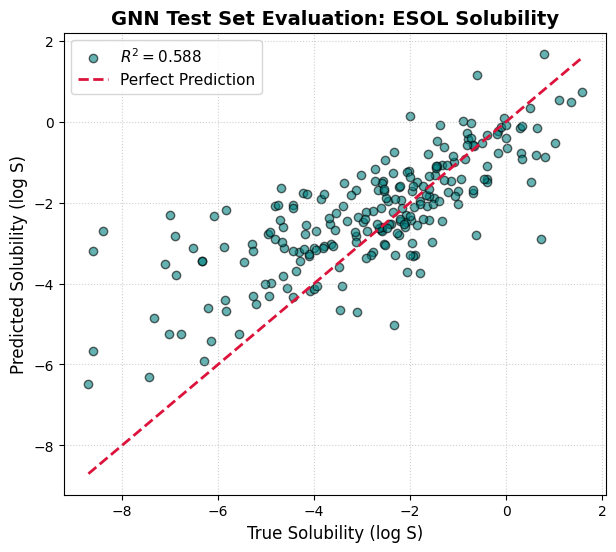

The correlation is strong between data and prediction!


In [27]:
import matplotlib.pyplot as plt
import numpy as np

def plot_predictions(loader, title="Model Predictions vs Ground Truth"):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for data in loader:
            out = model(data.x, data.edge_index, data.batch)
            all_preds.extend(out.view(-1).cpu().numpy())
            all_targets.extend(data.y.view(-1).cpu().numpy())

    # Convert to standard arrays
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)

    # Calculate R-squared value to assess the quality of correlation
    correlation_matrix = np.corrcoef(all_targets, all_preds)
    r_squared = correlation_matrix[0, 1] ** 2

    # Generate the scatter plot
    plt.figure(figsize=(7, 6))
    plt.scatter(all_targets, all_preds, alpha=0.6, color='teal', edgecolors='k', label=f'$R^2 = {r_squared:.3f}$')

    # Perfect alignment line (y = x)
    ideal_line = [min(all_targets), max(all_targets)]
    plt.plot(ideal_line, ideal_line, color='crimson', linestyle='--', linewidth=2, label='Perfect Prediction')

    plt.xlabel("True Solubility (log S)", fontsize=12)
    plt.ylabel("Predicted Solubility (log S)", fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()
    if np.sqrt(r_squared) > 0.6:
      print("The correlation is strong between data and prediction!")

# Render the plot for the test set
plot_predictions(test_loader, title="GNN Test Set Evaluation: ESOL Solubility")